# Python Statistical Distributions Cheatsheet

This cheat sheet summarizes usage, mathematical formulas, and visualizations for key statistical distributions in Python (using `scipy.stats` and `matplotlib`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, expon, logistic, t, lognorm, binom, poisson
from scipy.stats import uniform, beta, gamma, nbinom, geom, chi2

sns.set(style='whitegrid')

# Normal Distribution (Gaussian)
- Symmetric, bell-shaped, models many natural phenomena.
- Parameters: $\mu$ (mean, `loc`), $\sigma$ (std, `scale`)

**API / Usage:**
```python
norm.rvs(loc=0, scale=1, size=10)
norm.pdf(x, loc=0, scale=1)
norm.cdf(x, loc=0, scale=1)
norm.ppf(q, loc=0, scale=1)
```

**Equations:**

$$
\text{PDF: } f(x) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)
$$
$$
\text{CDF: } F(x) = \frac{1}{2}\left[1 + \operatorname{erf}\left(\frac{x-\mu}{\sigma\sqrt{2}}\right)\right]
$$
$$
\text{PPF: } Q(q) = \mu + \sigma \sqrt{2} \; \operatorname{erf}^{-1}(2q - 1)
$$

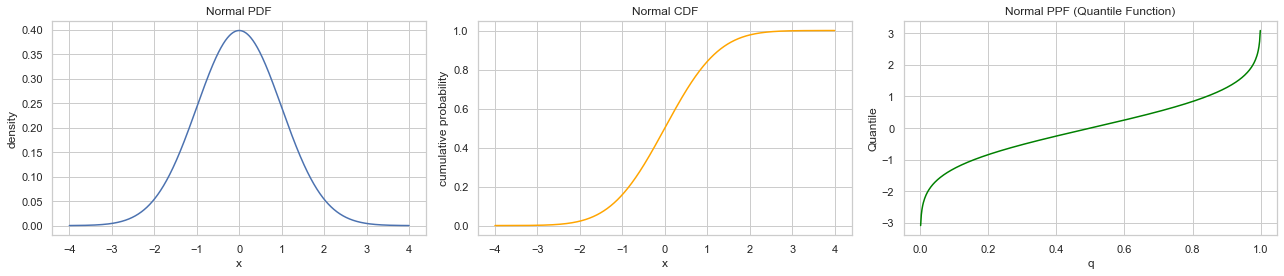

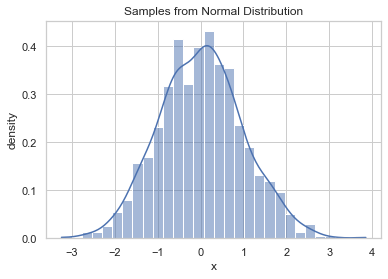

In [2]:
mu, sigma = 0, 1
x = np.linspace(-4, 4, 1000)
q = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, norm.pdf(x, mu, sigma), label='PDF')
plt.title('Normal PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, norm.cdf(x, mu, sigma), color='orange', label='CDF')
plt.title('Normal CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, norm.ppf(q, mu, sigma), color='green', label='PPF')
plt.title('Normal PPF (Quantile Function)')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = norm.rvs(loc=mu, scale=sigma, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Normal Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()

# Exponential Distribution
- Models waiting times (time until next event).
- Parameters: $\lambda$ (rate), `scale=1/\lambda`

**API / Usage:**
```python
expon.rvs(loc=0, scale=1, size=10)
expon.pdf(x, loc=0, scale=1)
expon.cdf(x, loc=0, scale=1)
expon.ppf(q, loc=0, scale=1)
```

**Equations:**

$$
\text{PDF: } f(x) = \lambda e^{-\lambda (x - a)},\; x\geq a
$$
$$
\text{CDF: } F(x) = 1 - e^{-\lambda (x - a)}
$$
$$
\text{PPF: } Q(q) = a - \frac{1}{\lambda} \ln(1 - q)
$$

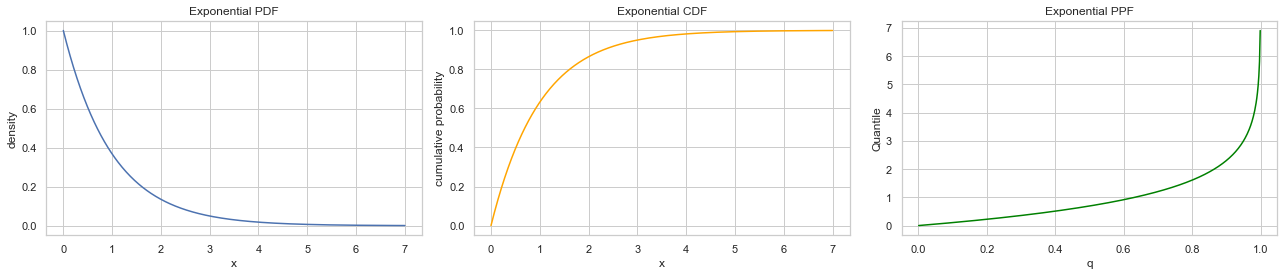

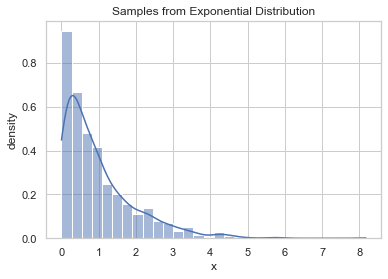

In [3]:
scale = 1  # scale = 1/lambda
loc = 0
x = np.linspace(0, 7, 500)
q = np.linspace(0.001, 0.999, 500)
plt.figure(figsize=(18,4))

plt.subplot(1,3,1)
plt.plot(x, expon.pdf(x, loc=loc, scale=scale), label='PDF')
plt.title('Exponential PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, expon.cdf(x, loc=loc, scale=scale), color='orange', label='CDF')
plt.title('Exponential CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, expon.ppf(q, loc=loc, scale=scale), color='green', label='PPF')
plt.title('Exponential PPF')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = expon.rvs(loc=loc, scale=scale, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Exponential Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()

# Logistic Distribution
- "S-shaped" CDF; common in ML/statistics (e.g., logistic regression).
- Parameters: $\mu$ (mean, `loc`), $s$ (scale)

**API / Usage:**
```python
logistic.rvs(loc=0, scale=1, size=10)
logistic.pdf(x, loc=0, scale=1)
logistic.cdf(x, loc=0, scale=1)
logistic.ppf(q, loc=0, scale=1)
```

**Equations:**
$$
\text{PDF: } f(x) = \frac{e^{-\frac{x-\mu}{s}}}{s (1 + e^{-\frac{x-\mu}{s}})^2}
$$
$$
\text{CDF: } F(x) = \frac{1}{1 + e^{-\frac{x-\mu}{s}}}
$$
$$
\text{PPF: } Q(q) = \mu + s \cdot \ln\left(\frac{q}{1 - q}\right)
$$

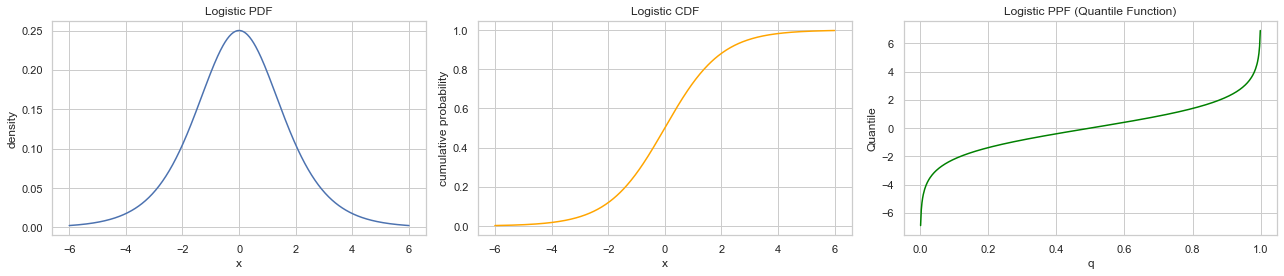

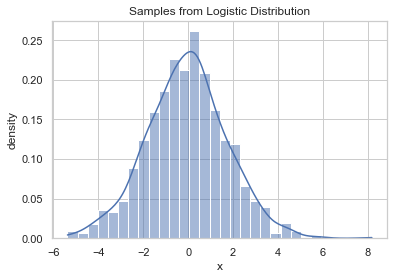

In [4]:
loc, scale = 0, 1
x = np.linspace(-6, 6, 500)
q = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, logistic.pdf(x, loc, scale))
plt.title('Logistic PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, logistic.cdf(x, loc, scale), color='orange')
plt.title('Logistic CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, logistic.ppf(q, loc, scale), color='green')
plt.title('Logistic PPF (Quantile Function)')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = logistic.rvs(loc=loc, scale=scale, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Logistic Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()

# Student's t-Distribution
- Estimating the population mean from small samples.
- Parameters: $\nu$ (degrees of freedom, `df`), $\mu$ (`loc`), $\sigma$ (`scale`)

**API / Usage:**
```python
t.rvs(df, loc=0, scale=1, size=10)
t.pdf(x, df, loc=0, scale=1)
t.cdf(x, df, loc=0, scale=1)
t.ppf(q, df, loc=0, scale=1)
```

**Equations:**
$$
\text{PDF: } f(x) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{(x-\mu)^2}{\nu\sigma^2}\right)^{-\frac{\nu+1}{2}}
$$
$$
\text{CDF: } F(x) = \int_{-\infty}^x f(t)\,dt
$$
$$
\text{PPF:} Q(q) = \text{Inverse CDF evaluated at } q
$$

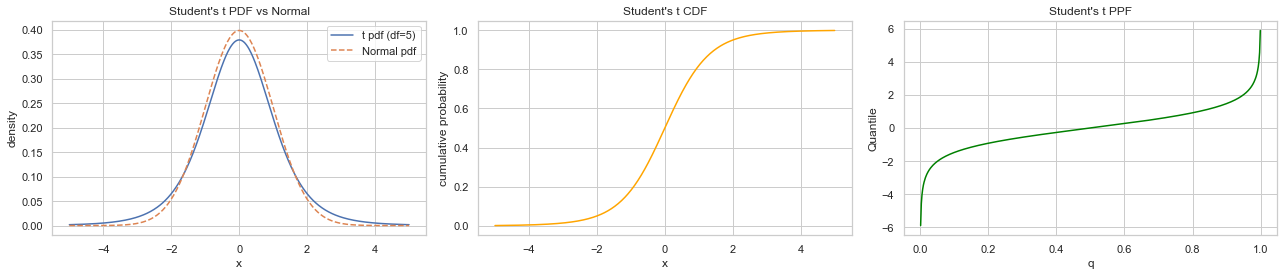

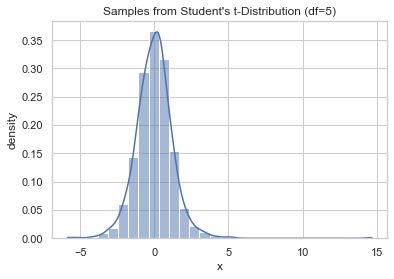

In [5]:
df = 5  # degrees of freedom
mu, sigma = 0, 1
x = np.linspace(-5, 5, 500)
q = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, t.pdf(x, df), label=f't pdf (df={df})')
plt.plot(x, norm.pdf(x), '--', label='Normal pdf')
plt.title("Student's t PDF vs Normal")
plt.xlabel('x'); plt.ylabel('density')
plt.legend()

plt.subplot(1,3,2)
plt.plot(x, t.cdf(x, df), color='orange')
plt.title("Student's t CDF")
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, t.ppf(q, df), color='green')
plt.title("Student's t PPF")
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = t.rvs(df, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title("Samples from Student's t-Distribution (df=5)")
plt.xlabel('x'); plt.ylabel('density')
plt.show()

# Lognormal Distribution
- Multiplicative effects, skewed right, $Y = \exp(X)$ where $X \sim N(\mu, \sigma^2)$
- Parameters: $s$ (shape, $\sigma$ in log-space), `scale=\exp(\mu)`

**API / Usage:**
```python
lognorm.rvs(s, loc=0, scale=1, size=10)
lognorm.pdf(x, s, loc=0, scale=1)
lognorm.cdf(x, s, loc=0, scale=1)
lognorm.ppf(q, s, loc=0, scale=1)
```

**Equations:**
$$
\text{PDF: } f(x) = \frac{1}{xs\sqrt{2\pi}}\exp\left( -\frac{(\ln x - \mu)^2}{2s^2}\right),\; x > 0
$$
$$
\text{CDF: } F(x) = \frac{1}{2} + \frac{1}{2} \operatorname{erf}\left(\frac{\ln x - \mu}{s\sqrt{2}}\right)
$$
$$
\text{PPF: } Q(q) = \exp\big[ \mu + s\sqrt{2} \,\operatorname{erf}^{-1}(2q-1)\big]
$$

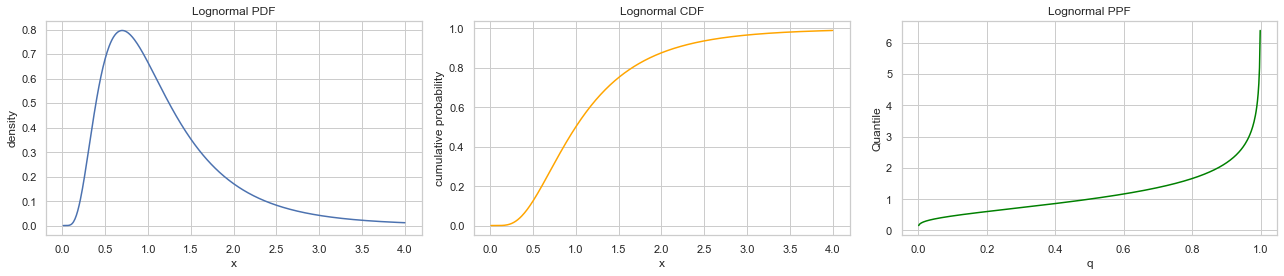

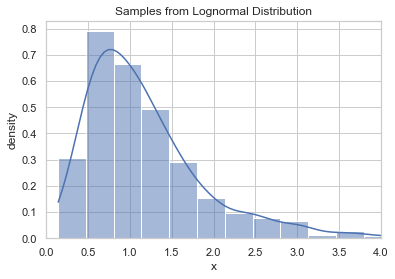

In [6]:
s = 0.6
scale = np.exp(0)
x = np.linspace(0.01, 4, 500)
q = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, lognorm.pdf(x, s, scale=scale), label='lognorm pdf')
plt.title('Lognormal PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, lognorm.cdf(x, s, scale=scale), color='orange', label='lognorm cdf')
plt.title('Lognormal CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, lognorm.ppf(q, s, scale=scale), color='green', label='lognorm ppf')
plt.title('Lognormal PPF')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = lognorm.rvs(s, scale=scale, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Lognormal Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.xlim(0, 4)
plt.show()

# Binomial Distribution
- Counts of successes in $n$ independent binary trials.
- Parameters: $n$ (trials), $p$ (success probability per trial)

**API / Usage:**
```python
binom.rvs(n, p, size=10)
binom.pmf(k, n, p)
binom.cdf(k, n, p)
binom.ppf(q, n, p)
```

**Equations:**
$$
\text{PMF: } P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}
$$
$$
\text{CDF: } F(k) = \sum_{j=0}^k P(X=j)
$$
$$
\text{PPF: } Q(q) = \min\{k \mid F(k) \geq q\}
$$

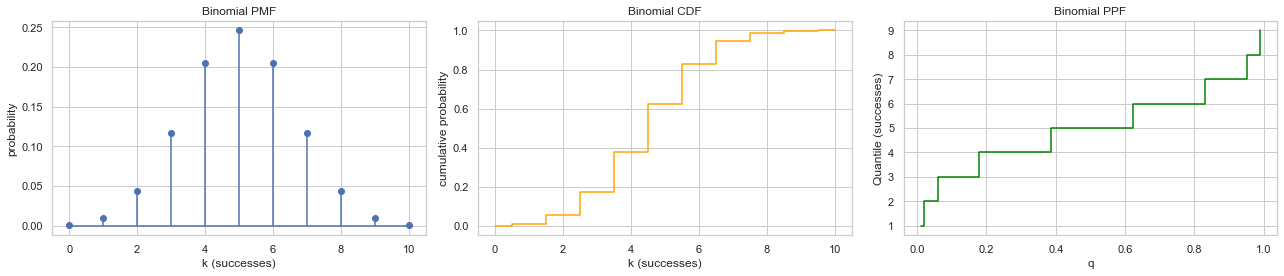

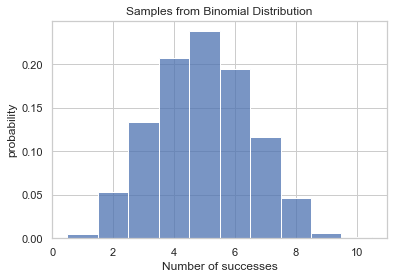

In [7]:
n, p = 10, 0.5
k = np.arange(0, n+1)
q = np.linspace(0, 1, n+1)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.stem(k, binom.pmf(k, n, p), basefmt='C0-', use_line_collection=True)
plt.title('Binomial PMF')
plt.xlabel('k (successes)'); plt.ylabel('probability')

plt.subplot(1,3,2)
plt.step(k, binom.cdf(k, n, p), where='mid', color='orange', label='binom cdf')
plt.title('Binomial CDF')
plt.xlabel('k (successes)'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
# For discrete, plot ppf as a step function
ppfs = [binom.ppf(qi, n, p) for qi in np.linspace(0.01, 0.99, 100)]
plt.plot(np.linspace(0.01, 0.99, 100), ppfs, drawstyle='steps-post', color='green')
plt.title('Binomial PPF')
plt.xlabel('q'); plt.ylabel('Quantile (successes)')
plt.tight_layout()
plt.show()

samples = binom.rvs(n, p, size=1000, random_state=42)
sns.histplot(samples, bins=np.arange(-0.5, n+1.5, 1), stat='probability', discrete=True)
plt.title('Samples from Binomial Distribution')
plt.xlabel('Number of successes'); plt.ylabel('probability')
plt.show()

# Poisson Distribution
- Counts of rare events in a fixed interval.
- Parameter: $\mu$ (mean rate per interval)

**API / Usage:**
```python
poisson.rvs(mu, size=10)
poisson.pmf(k, mu)
poisson.cdf(k, mu)
poisson.ppf(q, mu)
```

**Equations:**
$$
\text{PMF: } P(X=k) = \frac{e^{-\mu} \mu^k}{k!}
$$
$$
\text{CDF: } F(k) = \sum_{j=0}^k P(X=j)
$$
$$
\text{PPF: } Q(q) = \min\{k \mid F(k) \geq q\}
$$

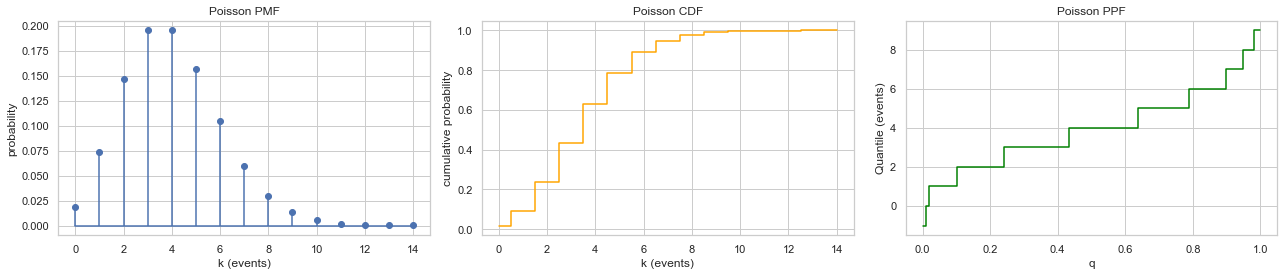

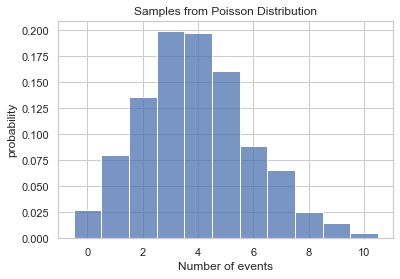

In [8]:
mu = 4
k = np.arange(0, 15)
qs = np.linspace(0, 1, 100)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.stem(k, poisson.pmf(k, mu), basefmt='C0-', use_line_collection=True)
plt.title('Poisson PMF')
plt.xlabel('k (events)'); plt.ylabel('probability')

plt.subplot(1,3,2)
plt.step(k, poisson.cdf(k, mu), where='mid', color='orange', label='poisson cdf')
plt.title('Poisson CDF')
plt.xlabel('k (events)'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
ppfs = [poisson.ppf(qi, mu) for qi in qs]
plt.plot(qs, ppfs, drawstyle='steps-post', color='green')
plt.title('Poisson PPF')
plt.xlabel('q'); plt.ylabel('Quantile (events)')
plt.tight_layout()
plt.show()

samples = poisson.rvs(mu, size=1000, random_state=42)
sns.histplot(samples, bins=np.arange(-0.5, 15.5, 1), stat='probability', discrete=True)
plt.title('Samples from Poisson Distribution')
plt.xlabel('Number of events'); plt.ylabel('probability')
plt.show()

# Uniform Distribution
- All values in $(a, b)$ equally likely.
- Parameters: $a$ (min, `loc`), $b$ (max, `loc + scale`)

**API / Usage:**
```python
uniform.rvs(loc=0, scale=1, size=10)
uniform.pdf(x, loc=0, scale=1)
uniform.cdf(x, loc=0, scale=1)
uniform.ppf(q, loc=0, scale=1)
```

**Equations:**
$$
\text{PDF: } f(x) = \frac{1}{b-a},\; a\leq x < b
$$
$$
\text{CDF: } F(x) = \frac{x-a}{b-a},\; a\leq x < b
$$
$$
\text{PPF: } Q(q) = a + q(b-a)
$$

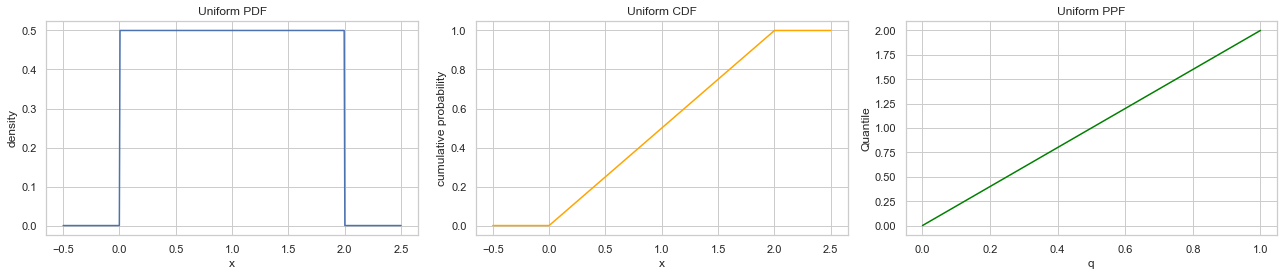

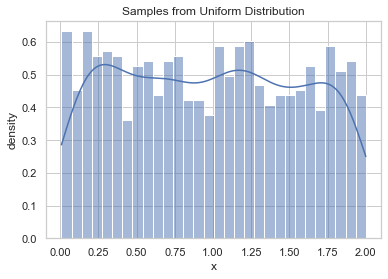

In [9]:
a, b = 0, 2
loc, scale = a, b - a
x = np.linspace(-0.5, 2.5, 500)
q = np.linspace(0, 1, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, uniform.pdf(x, loc, scale))
plt.title('Uniform PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, uniform.cdf(x, loc, scale), color='orange')
plt.title('Uniform CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, uniform.ppf(q, loc, scale), color='green')
plt.title('Uniform PPF')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = uniform.rvs(loc=loc, scale=scale, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Uniform Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()

# Beta Distribution
- Probabilities/proportions on $[0, 1]$; shape controlled by $\alpha, \beta$
- Parameters: $\alpha$ (`a`), $\beta$ (`b`), `loc`, `scale`

**API / Usage:**
```python
beta.rvs(a, b, size=10)
beta.pdf(x, a, b)
beta.cdf(x, a, b)
beta.ppf(q, a, b)
```

**Equations:**
$$
\text{PDF: } f(x) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1}(1-x)^{\beta-1},\; x\in(0,1)
$$
$$
\text{CDF: } F(x) = \int_0^x f(t)dt
$$
$$
\text{PPF: } Q(q) = F^{-1}(q)
$$

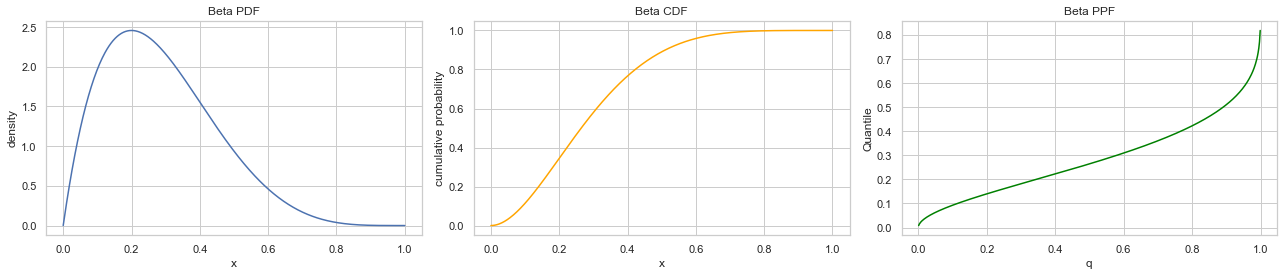

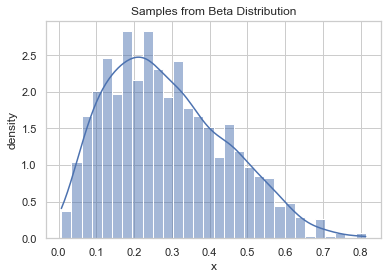

In [10]:
a, b = 2, 5
x = np.linspace(0, 1, 500)
q = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, beta.pdf(x, a, b))
plt.title('Beta PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, beta.cdf(x, a, b), color='orange')
plt.title('Beta CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, beta.ppf(q, a, b), color='green')
plt.title('Beta PPF')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = beta.rvs(a, b, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Beta Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()

# Gamma Distribution
- Models waiting times or sum of $\alpha$ exponential variables.
- Parameters: $k$ (`a`), $\theta$ (`scale`)

**API / Usage:**
```python
gamma.rvs(a, loc=0, scale=1, size=10)
gamma.pdf(x, a, loc=0, scale=1)
gamma.cdf(x, a, loc=0, scale=1)
gamma.ppf(q, a, loc=0, scale=1)
```

**Equations:**
$$
\text{PDF: } f(x) = \frac{1}{\Gamma(k)\theta^k} x^{k-1} e^{-x/\theta},\; x>0
$$
$$
\text{CDF: } F(x) = \frac{1}{\Gamma(k)} \gamma(k, x/\theta)
$$
$$
\text{PPF: } Q(q) = F^{-1}(q)
$$

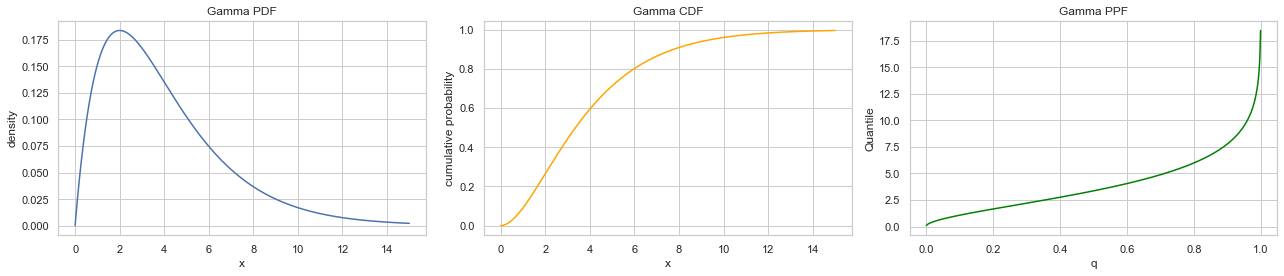

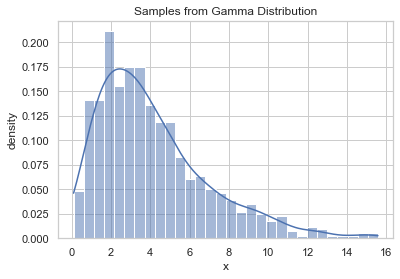

In [11]:
a, scale = 2, 2
x = np.linspace(0, 15, 500)
q = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, gamma.pdf(x, a, scale=scale))
plt.title('Gamma PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, gamma.cdf(x, a, scale=scale), color='orange')
plt.title('Gamma CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, gamma.ppf(q, a, scale=scale), color='green')
plt.title('Gamma PPF')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = gamma.rvs(a, scale=scale, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Gamma Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()

# Negative Binomial Distribution
- Discrete; number of failures before $r$ successes.
- Parameters: $r$ (number of successes, `n`), $p$ (success probability)

**API / Usage:**
```python
nbinom.rvs(r, p, size=10)
nbinom.pmf(k, r, p)
nbinom.cdf(k, r, p)
nbinom.ppf(q, r, p)
```

**Equations:**
$$
\text{PMF: } P(X=k) = \binom{k+r-1}{k} (1-p)^k p^r,\; k=0,1,2,...
$$
$$
\text{CDF: } F(k) = \sum_{j=0}^k P(X=j)
$$
$$
\text{PPF: } Q(q) = \min\{k \mid F(k) \geq q\}
$$

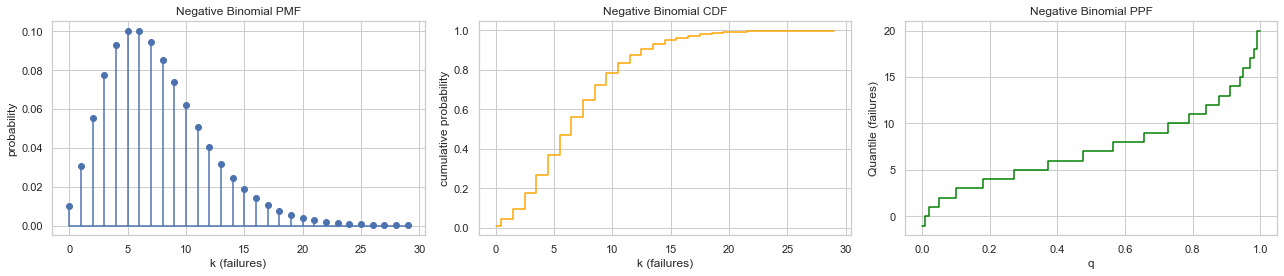

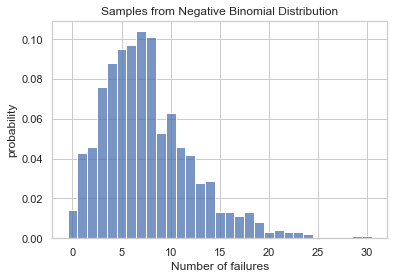

In [12]:
r, p = 5, 0.4
k = np.arange(0, 30)
qs = np.linspace(0, 1, 100)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.stem(k, nbinom.pmf(k, r, p), basefmt='C0-', use_line_collection=True)
plt.title('Negative Binomial PMF')
plt.xlabel('k (failures)'); plt.ylabel('probability')

plt.subplot(1,3,2)
plt.step(k, nbinom.cdf(k, r, p), where='mid', color='orange')
plt.title('Negative Binomial CDF')
plt.xlabel('k (failures)'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
ppfs = [nbinom.ppf(qi, r, p) for qi in qs]
plt.plot(qs, ppfs, drawstyle='steps-post', color='green')
plt.title('Negative Binomial PPF')
plt.xlabel('q'); plt.ylabel('Quantile (failures)')
plt.tight_layout()
plt.show()

samples = nbinom.rvs(r, p, size=1000, random_state=42)
sns.histplot(samples, bins=np.arange(-0.5, 30.5, 1), stat='probability', discrete=True)
plt.title('Samples from Negative Binomial Distribution')
plt.xlabel('Number of failures'); plt.ylabel('probability')
plt.show()

# Geometric Distribution
- Discrete; number of failures before first success.
- Parameter: $p$ (success probability)

**API / Usage:**
```python
geom.rvs(p, size=10)
geom.pmf(k, p)
geom.cdf(k, p)
geom.ppf(q, p)
```

**Equations:**
$$
\text{PMF: } P(X=k) = (1-p)^{k-1} p,\; k = 1, 2, ...
$$
$$
\text{CDF: } F(k) = 1 - (1-p)^{k}
$$
$$
\text{PPF: } Q(q) = \lceil \frac{\ln(1-q)}{\ln(1-p)} \rceil
$$

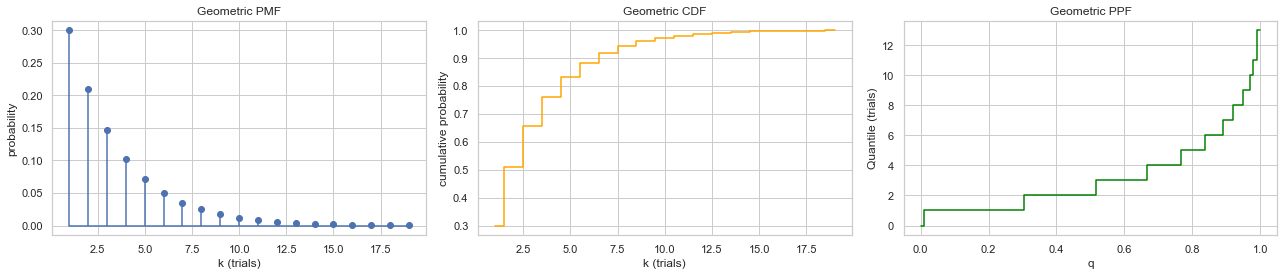

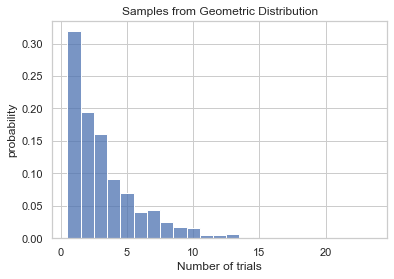

In [13]:
p = 0.3
k = np.arange(1, 20)
qs = np.linspace(0, 1, 100)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.stem(k, geom.pmf(k, p), basefmt='C0-', use_line_collection=True)
plt.title('Geometric PMF')
plt.xlabel('k (trials)'); plt.ylabel('probability')

plt.subplot(1,3,2)
plt.step(k, geom.cdf(k, p), where='mid', color='orange')
plt.title('Geometric CDF')
plt.xlabel('k (trials)'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
ppfs = [geom.ppf(qi, p) for qi in qs]
plt.plot(qs, ppfs, drawstyle='steps-post', color='green')
plt.title('Geometric PPF')
plt.xlabel('q'); plt.ylabel('Quantile (trials)')
plt.tight_layout()
plt.show()

samples = geom.rvs(p, size=1000, random_state=42)
sns.histplot(samples, bins=np.arange(0.5, 20.5, 1), stat='probability', discrete=True)
plt.title('Samples from Geometric Distribution')
plt.xlabel('Number of trials'); plt.ylabel('probability')
plt.show()

# Chi-squared Distribution
- Distribution of sum of squares of $k$ standard normal random variables (common in hypothesis testing).
- Parameter: $k$ (degrees of freedom, `df`)

**API / Usage:**
```python
chi2.rvs(df, size=10)
chi2.pdf(x, df)
chi2.cdf(x, df)
chi2.ppf(q, df)
```

**Equations:**
$$
\text{PDF: } f(x) = \frac{1}{2^{k/2}\Gamma(k/2)} x^{k/2 - 1} e^{-x/2},\; x>0
$$
$$
\text{CDF: } F(x) = P\left( \frac{k}{2}, \frac{x}{2} \right)
$$
$$
\text{PPF: } Q(q) = F^{-1}(q)
$$

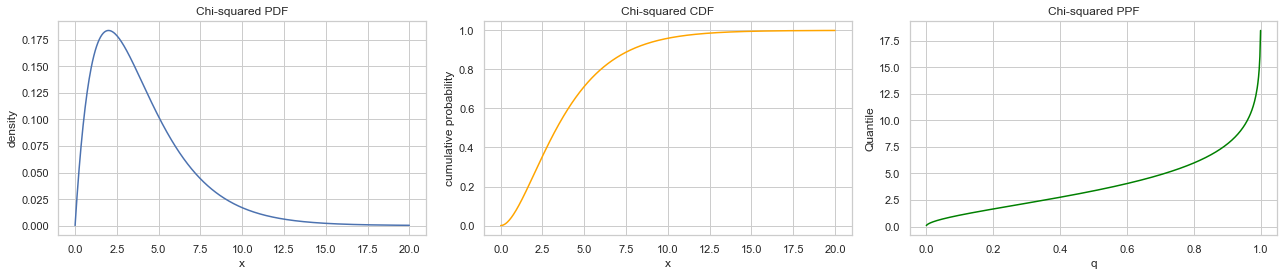

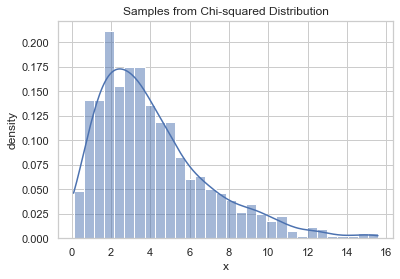

In [14]:
df = 4
x = np.linspace(0, 20, 500)
q = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.plot(x, chi2.pdf(x, df))
plt.title('Chi-squared PDF')
plt.xlabel('x'); plt.ylabel('density')

plt.subplot(1,3,2)
plt.plot(x, chi2.cdf(x, df), color='orange')
plt.title('Chi-squared CDF')
plt.xlabel('x'); plt.ylabel('cumulative probability')

plt.subplot(1,3,3)
plt.plot(q, chi2.ppf(q, df), color='green')
plt.title('Chi-squared PPF')
plt.xlabel('q'); plt.ylabel('Quantile')
plt.tight_layout()
plt.show()

samples = chi2.rvs(df, size=1000, random_state=42)
sns.histplot(samples, bins=30, kde=True, stat='density')
plt.title('Samples from Chi-squared Distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()